# SYNERGY+ dataset statistics

SYNERGY+ is a collection of systematic review datasets, each containing the records
a review screened plus the reviewers' inclusion decisions. This notebook profiles
the **SYNERGY+** release, which ships as:

- one CSV per review directly under `data/synergy_plus/` (e.g. `Abgaz_2023.csv`),
  with one row per screened record and columns `openalex_id`, `doi`, `pmid`,
  `lens_id`, `title`, `abstract`, `label_included`, and (where available)
  `label_abstract_included`;
- `data/synergy_plus/metadata/review_metadata.csv`, one row per review, describing
  how the review itself was conducted (screening process, review type, the
  review publication's own open-access status, reported corpus sizes, ...).

It answers a few practical questions for anyone building or evaluating screening
models on this data:

- How big are the datasets, and how selective is each review?
- Do reviews' searches overlap, and do overlapping records get consistent labels?
- How rigorously were they screened (single vs. double reviewers)?
- What kind of reviews make up the corpus, and how open-access are they?
- How complete is the record-level metadata (abstracts, identifiers)?
- How much text and vocabulary does each dataset actually contain?

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import CountVectorizer

DATA_DIR = Path("..", "..", "..", "data", "synergy_plus")
METADATA_PATH = DATA_DIR / "metadata" / "review_metadata.csv"

# Palette: one accent hue for magnitude comparisons, a fixed-order categorical
# set for identity comparisons (review type, OA status), muted tones for chrome.
BLUE = "#2a78d6"
ORANGE = "#eb6834"
GRAY = "#898781"
CATEGORICAL = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
]
GRID = "#e1e0d9"
INK = "#0b0b0b"
SECONDARY_INK = "#52514e"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": GRID,
        "axes.labelcolor": SECONDARY_INK,
        "text.color": INK,
        "xtick.color": SECONDARY_INK,
        "ytick.color": SECONDARY_INK,
        "axes.grid": False,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

## Loading the data

Each review contributes one CSV, named after the dataset, directly under `data/synergy_plus/`. We stack them into a single record-level table and tag every row with its `dataset_id`, then load the review-level metadata separately (it describes each *review*, not each record).

In [2]:
frames = []
for f in sorted(DATA_DIR.glob("*.csv")):
    df = pd.read_csv(f)
    df["dataset_id"] = f.stem
    frames.append(df)

records = pd.concat(frames, ignore_index=True)
records["abstract_word_count"] = records["abstract"].str.split().str.len()

reviews = pd.read_csv(METADATA_PATH).set_index("key")

records.head()

,openalex_id,doi,pmid,lens_id,title,abstract,label_included,label_abstract_included,dataset_id,abstract_word_count
0,https://openalex.org/w3028783161,https://doi.org/10.1109/icsa47634.2020.00023,NaN,060-939-344-289-222,From Monolithic Architecture Style to Microser...,"Due to its tremendous advantages, microservice...",1,1.0,Abgaz_2023,186
1,https://openalex.org/w3163266571,https://doi.org/10.3390/app11104350,NaN,024-096-260-278-819,Evaluating Service-Oriented and Microservice A...,This article proposes a new framework for a Cl...,0,0.0,Abgaz_2023,200
2,https://openalex.org/w3068636631,https://doi.org/10.1016/j.jss.2020.110798,NaN,093-944-352-652-195,A Systematic Mapping Study on Microservices Ar...,Context: Applying Microservices Architecture (...,0,0.0,Abgaz_2023,200
3,https://openalex.org/w2908689186,https://doi.org/10.7763/ijcte.2018.v10.1219,NaN,057-404-017-637-809,An Approach to Evolving Legacy Enterprise Syst...,Evolving legacy enterprise systems into a lean...,0,0.0,Abgaz_2023,173
4,https://openalex.org/w4297063250,https://doi.org/10.1007/978-3-319-70578-1_16,NaN,057-005-583-452-253,Joining Jolie to Docker,"Cloud computing is steadily growing and, as Ia...",0,0.0,Abgaz_2023,104


## Dataset overview

In [ ]:
n_records = len(records)
n_datasets = records["dataset_id"].nunique()
size_per_dataset = records.groupby("dataset_id").size()
split_counts = reviews["split"].value_counts()

size_mismatches = (size_per_dataset - reviews["n_records"]).abs().gt(0).sum()

display(
    Markdown(
        f"**{n_records:,} records** across **{n_datasets} datasets**, "
        f"ranging from {size_per_dataset.min():,} to {size_per_dataset.max():,} records "
        f"per dataset (median {int(size_per_dataset.median()):,}). "
        f"{split_counts.get('train', 0)} datasets are in the `train` split, "
        f"{split_counts.get('test', 0)} in `test`. "
        f"Record counts agree with the reviews' reported `n_records` for "
        f"{n_datasets - size_mismatches}/{n_datasets} datasets."
    )
)

**168,969 records** across **114 datasets**, ranging from 54 to 11,735 records per dataset (median 742). 91 datasets are in the `train` split, 23 in `test`. Record counts agree with the reviews' reported `n_records` for 114/114 datasets.

## Duplicate records across datasets

Several reviews' searches overlap topically, so the same `openalex_id` can appear in more than one dataset. That matters for anyone training across multiple datasets at once: a record seen during training in one dataset could reappear in another dataset's test split.

In [ ]:
dup_mask = records["openalex_id"].duplicated(keep=False)
n_duplicated_rows = dup_mask.sum()
n_duplicated_ids = records.loc[dup_mask, "openalex_id"].nunique()

label_spread = records.loc[dup_mask].groupby("openalex_id")["label_included"].nunique()
n_conflicting = (label_spread > 1).sum()

display(
    Markdown(
        f"**{n_duplicated_rows:,} rows** ({n_duplicated_rows / n_records * 100:.1f}% of the corpus) share an "
        f"`openalex_id` with at least one other dataset, covering **{n_duplicated_ids:,} distinct records**. "
        f"Of those, **{n_conflicting:,}** are labeled `included` in one dataset and `excluded` in another — "
        "worth deduplicating or reconciling before pooling datasets for training."
    )
)

**23,724 rows** (14.0% of the corpus) share an `openalex_id` with at least one other dataset, covering **10,722 distinct records**. Of those, **715** are labeled `included` in one dataset and `excluded` in another — worth deduplicating or reconciling before pooling datasets for training.

## Screening funnel

Reviews screen in (up to) two stages: an abstract-level pass (`label_abstract_included`) followed by a full-text pass (`label_included`). Not every review records a separate abstract-level decision, so that column is missing or `NaN` for reviews that only screened full text.

In [ ]:
datasets_with_ab_stage = records.groupby("dataset_id")["label_abstract_included"].apply(
    lambda s: s.notna().any() if "label_abstract_included" in records.columns else False
)
ab_rate = records["label_abstract_included"].mean() * 100
ft_rate = records["label_included"].mean() * 100

display(
    Markdown(
        f"- {int(datasets_with_ab_stage.sum())} of {n_datasets} datasets record a separate abstract-level decision.\n"
        f"- Abstract-level inclusion rate (where recorded): **{ab_rate:.1f}%**\n"
        f"- Full-text inclusion rate (all datasets): **{ft_rate:.1f}%**"
    )
)

- 53 of 114 datasets record a separate abstract-level decision.
- Abstract-level inclusion rate (where recorded): **6.5%**
- Full-text inclusion rate (all datasets): **2.6%**

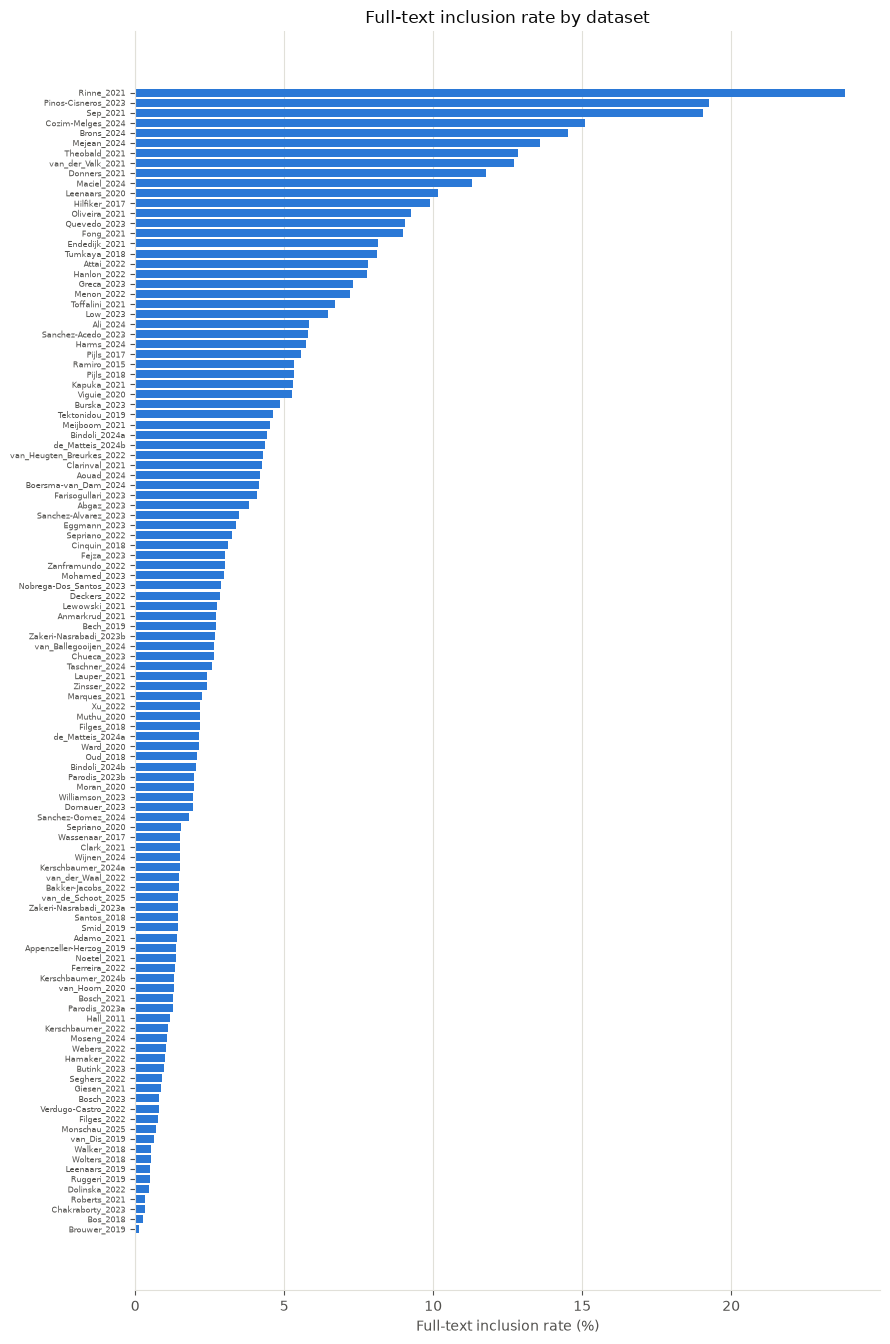

In [ ]:
ft_by_dataset = (
    records.groupby("dataset_id")["label_included"].mean().mul(100).sort_values()
)

fig, ax = plt.subplots(figsize=(9, 0.11 * n_datasets + 1))
ax.barh(ft_by_dataset.index, ft_by_dataset.values, color=BLUE)
ax.grid(axis="x")
ax.tick_params(axis="y", labelsize=6)
ax.set_xlabel("Full-text inclusion rate (%)")
ax.set_title("Full-text inclusion rate by dataset")
fig.tight_layout()
plt.show()

In [ ]:
zero_inclusion = ft_by_dataset[ft_by_dataset == 0]

display(
    Markdown(
        f"Most selective: **{ft_by_dataset.index[-1]}** at {ft_by_dataset.iloc[-1]:.1f}%. "
        f"Least selective: **{ft_by_dataset.index[0]}** at {ft_by_dataset.iloc[0]:.1f}%. "
        f"{len(zero_inclusion)} dataset(s) have zero full-text inclusions"
        f"{': ' + ', '.join(zero_inclusion.index) if len(zero_inclusion) else ''}."
    )
)

Most selective: **Rinne_2021** at 23.8%. Least selective: **Brouwer_2019** at 0.1%. 0 dataset(s) have zero full-text inclusions.

## The review process

`review_metadata.csv` describes each review's own methodology — one row per review, not per record. This is where screening rigor and review characteristics live.

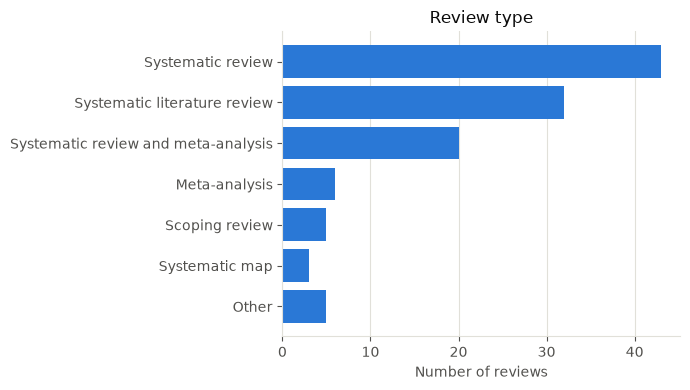

In [8]:
review_type_counts = reviews["review_type"].value_counts()
top_types = review_type_counts.head(6)
other_types = review_type_counts.iloc[6:].sum()
if other_types:
    top_types = pd.concat([top_types, pd.Series({"Other": other_types})])

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top_types.index[::-1], top_types.values[::-1], color=BLUE)
ax.grid(axis="x")
ax.set_xlabel("Number of reviews")
ax.set_title("Review type")
fig.tight_layout()
plt.show()

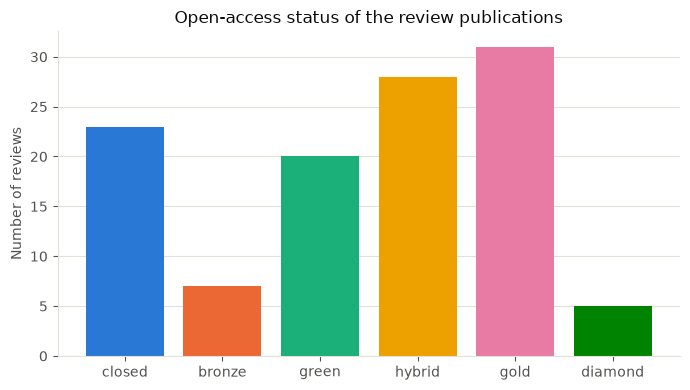

Note: this is the open-access status of the *review paper itself*, not of the individual records it screened.

In [ ]:
oa_order = ["closed", "bronze", "green", "hybrid", "gold", "diamond"]
review_oa_share = (
    reviews["open_access_status"].value_counts().reindex(oa_order).dropna()
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    review_oa_share.index,
    review_oa_share.values,
    color=CATEGORICAL[: len(review_oa_share)],
)
ax.grid(axis="y")
ax.set_ylabel("Number of reviews")
ax.set_title("Open-access status of the review publications")
fig.tight_layout()
plt.show()

display(
    Markdown(
        "Note: this is the open-access status of the *review paper itself*, not of the individual "
        "records it screened."
    )
)

Screening rigor matters for label quality: a single screener is more error-prone than two independent screeners reconciling disagreements. How many reviews report each?

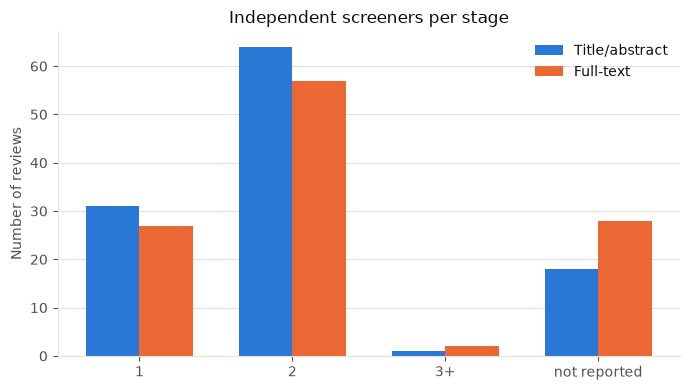

**27%** of reviews report a single screener at the title/abstract stage — worth knowing before treating those labels as noise-free ground truth.

In [ ]:
def bucket_screeners(s):
    n = pd.to_numeric(s, errors="coerce")
    return n.map(
        lambda x: (
            "not reported"
            if pd.isna(x)
            else ("1" if x == 1 else ("2" if x == 2 else "3+"))
        )
    )


screener_order = ["1", "2", "3+", "not reported"]
rigor = pd.DataFrame(
    {
        "Title/abstract": bucket_screeners(reviews["ti_ab_screeners"])
        .value_counts()
        .reindex(screener_order)
        .fillna(0),
        "Full-text": bucket_screeners(reviews["ft_screeners"])
        .value_counts()
        .reindex(screener_order)
        .fillna(0),
    }
)

x = range(len(screener_order))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    [i - width / 2 for i in x],
    rigor["Title/abstract"],
    width,
    label="Title/abstract",
    color=BLUE,
)
ax.bar(
    [i + width / 2 for i in x],
    rigor["Full-text"],
    width,
    label="Full-text",
    color=ORANGE,
)
ax.set_xticks(list(x))
ax.set_xticklabels(screener_order)
ax.grid(axis="y")
ax.set_ylabel("Number of reviews")
ax.set_title("Independent screeners per stage")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

single_reviewer_pct = (bucket_screeners(reviews["ti_ab_screeners"]) == "1").mean() * 100
display(
    Markdown(
        f"**{single_reviewer_pct:.0f}%** of reviews report a single screener at the title/abstract stage — "
        "worth knowing before treating those labels as noise-free ground truth."
    )
)

## Record-level metadata completeness

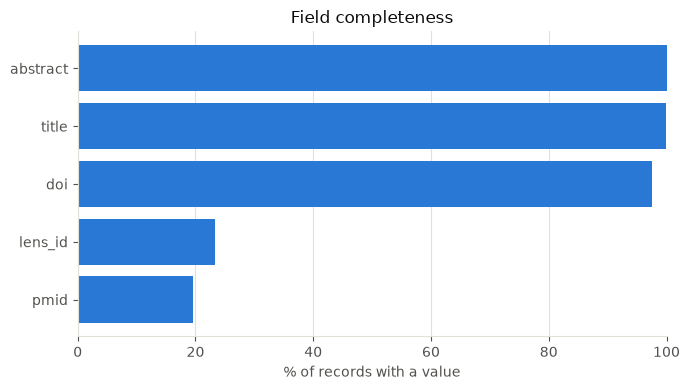

In [ ]:
completeness = (
    pd.Series(
        {
            "title": records["title"].notna().mean(),
            "abstract": records["abstract"].notna().mean(),
            "doi": records["doi"].notna().mean(),
            "pmid": records["pmid"].notna().mean(),
            "lens_id": records["lens_id"].notna().mean(),
        }
    )
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(completeness.index, completeness.values, color=BLUE)
ax.grid(axis="x")
ax.set_xlim(0, 100)
ax.set_xlabel("% of records with a value")
ax.set_title("Field completeness")
fig.tight_layout()
plt.show()

`pmid` and `lens_id` coverage is partial by design — not every record is indexed in PubMed or resolvable in Lens.org. `title` and `abstract` are what matter most for text-based screening models, and both are effectively complete.

## Abstract length

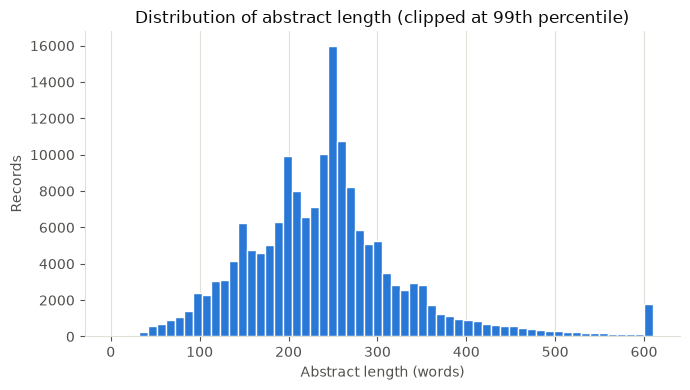

Median abstract length is **241 words** (mean 244, max 2,020).

In [ ]:
word_counts = records["abstract_word_count"].dropna()
clip_at = word_counts.quantile(0.99)

fig, ax = plt.subplots(figsize=(7, 4))
word_counts.clip(upper=clip_at).hist(bins=60, color=BLUE, edgecolor="white", ax=ax)
ax.grid(axis="y")
ax.set_xlabel("Abstract length (words)")
ax.set_ylabel("Records")
ax.set_title("Distribution of abstract length (clipped at 99th percentile)")
fig.tight_layout()
plt.show()

display(
    Markdown(
        f"Median abstract length is **{word_counts.median():.0f} words** "
        f"(mean {word_counts.mean():.0f}, max {int(word_counts.max()):,})."
    )
)

Does abstract length differ between records that survive full-text screening and those that don't? A systematic difference could indicate a usable signal for triage models, or could reveal a screening artifact worth investigating.

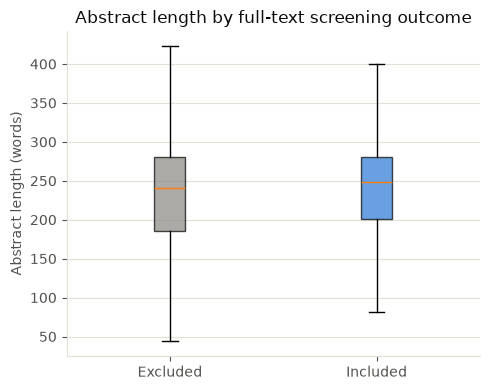

Median length is **248 words** for included records vs. **241 words** for excluded records.

In [ ]:
comparison = records.dropna(subset=["abstract_word_count"]).copy()
comparison["stage"] = comparison["label_included"].map({1: "Included", 0: "Excluded"})

fig, ax = plt.subplots(figsize=(5, 4))
box_data = [
    comparison.loc[comparison["stage"] == "Excluded", "abstract_word_count"],
    comparison.loc[comparison["stage"] == "Included", "abstract_word_count"],
]
bp = ax.boxplot(
    box_data, tick_labels=["Excluded", "Included"], patch_artist=True, showfliers=False
)
for patch, color in zip(bp["boxes"], [GRAY, BLUE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.grid(axis="y")
ax.set_ylabel("Abstract length (words)")
ax.set_title("Abstract length by full-text screening outcome")
fig.tight_layout()
plt.show()

medians = comparison.groupby("stage")["abstract_word_count"].median()
display(
    Markdown(
        f"Median length is **{medians['Included']:.0f} words** for included records vs. "
        f"**{medians['Excluded']:.0f} words** for excluded records."
    )
)

## Vocabulary size

Unique unigrams and bigrams in the titles and abstracts of each dataset, as a rough proxy for topical breadth and text volume — a dataset with a large corpus but a small vocabulary is likely narrowly focused, while a large vocabulary suggests broader or noisier terminology.

In [ ]:
def count_terms(texts, ngram_range):
    return (
        CountVectorizer(ngram_range=ngram_range)
        .fit_transform(texts.fillna(""))
        .shape[1]
    )


vocab_rows = []
for dataset_id, group in records.groupby("dataset_id"):
    vocab_rows.append(
        {
            "dataset_id": dataset_id,
            "title unigrams": count_terms(group["title"], (1, 1)),
            "abstract unigrams": count_terms(group["abstract"], (1, 1)),
            "title bigrams": count_terms(group["title"], (2, 2)),
            "abstract bigrams": count_terms(group["abstract"], (2, 2)),
        }
    )

vocab = pd.DataFrame(vocab_rows).set_index("dataset_id")
vocab.sort_values("abstract unigrams", ascending=False).head(10)

,title unigrams,abstract unigrams,title bigrams,abstract bigrams
dataset_id,,,,
Walker_2018,20132,66031,82549,830322
Brouwer_2019,10817,43191,60670,720759
Webers_2022,11387,41143,49129,586995
Monschau_2025,8634,34534,42761,565257
Hilfiker_2017,9084,34003,42371,524088
van_de_Schoot_2025,8195,32837,41357,491107
Parodis_2023a,7805,30718,27714,343055
Dolinska_2022,6424,25925,22840,275586
Lauper_2021,6789,25049,33540,395576


## Summary

In [ ]:
display(
    Markdown(
        f"""
- **{n_records:,} records** across **{n_datasets} datasets** (median {int(size_per_dataset.median()):,} records/dataset).
- **{n_duplicated_ids:,} records** appear in more than one dataset; **{n_conflicting:,}** of those carry conflicting inclusion labels across reviews.
- Full-text inclusion rate is **{ft_rate:.1f}%** overall, ranging from {ft_by_dataset.iloc[0]:.1f}% to {ft_by_dataset.iloc[-1]:.1f}% by dataset.
- **{single_reviewer_pct:.0f}%** of reviews used a single screener at the title/abstract stage.
- Review publications span all open-access categories, led by {review_oa_share.idxmax()} ({review_oa_share.max()} reviews).
- Record-level `title` and `abstract` fields are essentially complete ({completeness["title"]:.1f}% / {completeness["abstract"]:.1f}%); `pmid` ({completeness["pmid"]:.1f}%) and `lens_id` ({completeness["lens_id"]:.1f}%) are only partially populated.
"""
    )
)


- **168,969 records** across **114 datasets** (median 742 records/dataset).
- **10,722 records** appear in more than one dataset; **715** of those carry conflicting inclusion labels across reviews.
- Full-text inclusion rate is **2.6%** overall, ranging from 0.1% to 23.8% by dataset.
- **27%** of reviews used a single screener at the title/abstract stage.
- Review publications span all open-access categories, led by gold (31 reviews).
- Record-level `title` and `abstract` fields are essentially complete (100.0% / 100.0%); `pmid` (19.6%) and `lens_id` (23.3%) are only partially populated.
